# 🍕 Pizza Sales Data — End-to-End Python Data Analysis

## 🎯 Objective

- Revenue trends and overall pizza sales performance

- Top-performing pizza categories, sizes, and specific items

- Customer ordering behavior, including average order values and items per order

- The popularity of specific ingredients to help optimize inventory

- Peak ordering times and volume trends

- Key factors driving business growth and profitability

## 📌 Problem Statement
A pizza business needs data-driven insights to optimize sales, identify popular products, understand customer demand across time periods, and improve decision-making.

## 📚 Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 📥 Load Dataset

In [2]:
df=pd.read_csv(r"C:\Users\A\OneDrive\Desktop\Power BI-P\Pizza Sales\Dataset\pizza_sales.csv")

##  Preview Dataset

In [3]:
df.head(5)

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,01-01-2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,01-01-2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,01-01-2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,01-01-2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,01-01-2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


## 📊 Dataset Shape Analysis

In [4]:
print("The Metadata of the dataset: ", df.shape)

The Metadata of the dataset:  (48620, 12)


In [5]:
print("The Rows of the dataset: ", df.shape[0])

The Rows of the dataset:  48620


In [6]:
print("The Columns of the dataset: ", df.shape[1])

The Columns of the dataset:  12


## 🏷️ Column Information

In [7]:
df.columns

Index(['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_date',
       'order_time', 'unit_price', 'total_price', 'pizza_size',
       'pizza_category', 'pizza_ingredients', 'pizza_name'],
      dtype='str')

## 🔍 Dataset Information

In [8]:
print("Dataset Information:")
df.info()

print("\nData Types:")
display(df.dtypes)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48620 non-null  str    
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  str    
 5   order_time         48620 non-null  str    
 6   unit_price         48620 non-null  float64
 7   total_price        48620 non-null  float64
 8   pizza_size         48620 non-null  str    
 9   pizza_category     48620 non-null  str    
 10  pizza_ingredients  48620 non-null  str    
 11  pizza_name         48620 non-null  str    
dtypes: float64(2), int64(3), str(7)
memory usage: 4.5 MB

Data Types:


pizza_id               int64
order_id               int64
pizza_name_id            str
quantity               int64
order_date               str
order_time               str
unit_price           float64
total_price          float64
pizza_size               str
pizza_category           str
pizza_ingredients        str
pizza_name               str
dtype: object

## 🧾 Data Types Check

In [9]:
df.dtypes

pizza_id               int64
order_id               int64
pizza_name_id            str
quantity               int64
order_date               str
order_time               str
unit_price           float64
total_price          float64
pizza_size               str
pizza_category           str
pizza_ingredients        str
pizza_name               str
dtype: object

# 🧹 Data Cleaning 

In [10]:
df.isnull().sum()

pizza_id             0
order_id             0
pizza_name_id        0
quantity             0
order_date           0
order_time           0
unit_price           0
total_price          0
pizza_size           0
pizza_category       0
pizza_ingredients    0
pizza_name           0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

## 📈 Statistical Summary

In [12]:
df.describe()

,pizza_id,order_id,quantity,unit_price,total_price
count,48620.000000,48620.000000,48620.000000,48620.000000,48620.000000
mean,24310.500000,10701.479761,1.019622,16.494132,16.821474
std,14035.529381,6180.119770,0.143077,3.621789,4.437398
min,1.000000,1.000000,1.000000,9.750000,9.750000
25%,12155.750000,5337.000000,1.000000,12.750000,12.750000
50%,24310.500000,10682.500000,1.000000,16.500000,16.500000
75%,36465.250000,16100.000000,1.000000,20.250000,20.500000
max,48620.000000,21350.000000,4.000000,35.950000,83.000000


## 💰 Key Business KPIs

In [13]:
total_revenue = df['total_price'].sum()
total_pizzas_sold = df['quantity'].sum()
total_orders = df['order_id'].nunique()
avg_order_value = total_revenue / total_orders
avg_pizzas_per_order = total_pizzas_sold / total_orders

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Pizzas Sold: {total_pizzas_sold:,}")
print(f"Total Orders: {total_orders:,}")
print(f"Avg Order Value: ${avg_order_value:.2f}")
print(f"Average Pizza per Order: {avg_pizzas_per_order:.2f}")

Total Revenue: $817,860.05
Total Pizzas Sold: 49,574
Total Orders: 21,350
Avg Order Value: $38.31
Average Pizza per Order: 2.32


## 🧩 Feature Engineering

Create reusable date/time features once so later analysis does not repeat the same transformations.

In [14]:
df['day_name'] = df['order_date'].dt.day_name()
df['order_hour'] = df['order_time'].dt.hour
df['month'] = df['order_date'].dt.to_period('M')

weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]
df['day_name'] = pd.Categorical(
    df['day_name'],
    categories=weekday_order,
    ordered=True
)

df['day_type'] = np.where(
    df['order_date'].dt.dayofweek >= 5,
    'Weekend',
    'Weekday'
)

print("Feature engineering completed.")
display(df[['order_date', 'order_time', 'day_name', 'order_hour', 'month', 'day_type']].head())

AttributeError: Can only use .dt accessor with datetimelike values

## 🧀 Most Used Pizza Ingredients

In [ ]:
ingredient = (
    df['pizza_ingredients']
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .reset_index()
    .rename(columns={'index':'Ingredients',
                     'pizza_ingredients':'counts'})
)

print(ingredient.head(10))

              counts  count
0             Garlic  27422
1           Tomatoes  26601
2         Red Onions  19547
3        Red Peppers  16284
4  Mozzarella Cheese  10333
5          Pepperoni  10300
6            Spinach  10012
7          Mushrooms   9624
8            Chicken   8443
9          Capocollo   6572


## 📅 Orders

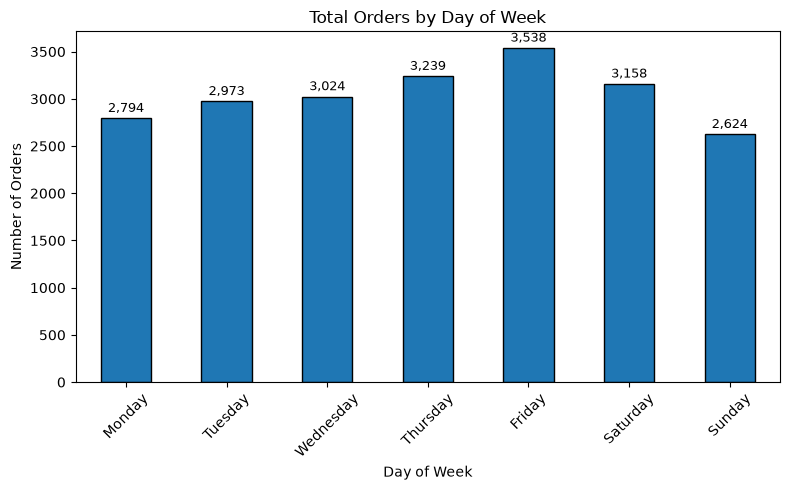

In [ ]:
orders_by_day = (
    df.groupby('day_name', observed=False)['order_id']
      .nunique()
)

ax = orders_by_day.plot(
    kind='bar',
    figsize=(8, 5),
    edgecolor='black'
)

plt.title("Total Orders by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

for idx, val in enumerate(orders_by_day):
    ax.text(
        idx, val + orders_by_day.max() * 0.01,
        f"{val:,}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

## 💵 Revenue 

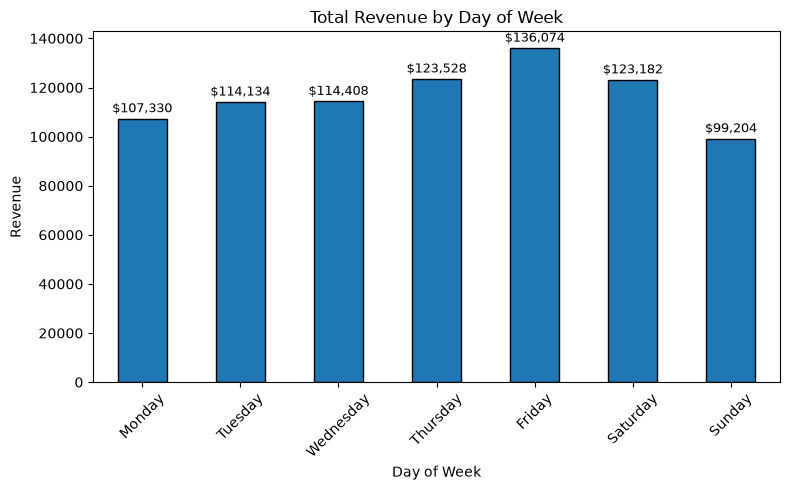

In [ ]:
revenue_by_day = (
    df.groupby('day_name', observed=False)['total_price']
      .sum()
)

ax = revenue_by_day.plot(
    kind='bar',
    figsize=(8, 5),
    edgecolor='black'
)

plt.title("Total Revenue by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

for idx, val in enumerate(revenue_by_day):
    ax.text(
        idx, val + revenue_by_day.max() * 0.01,
        f"${val:,.0f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

## ⏰ Orders by Hour

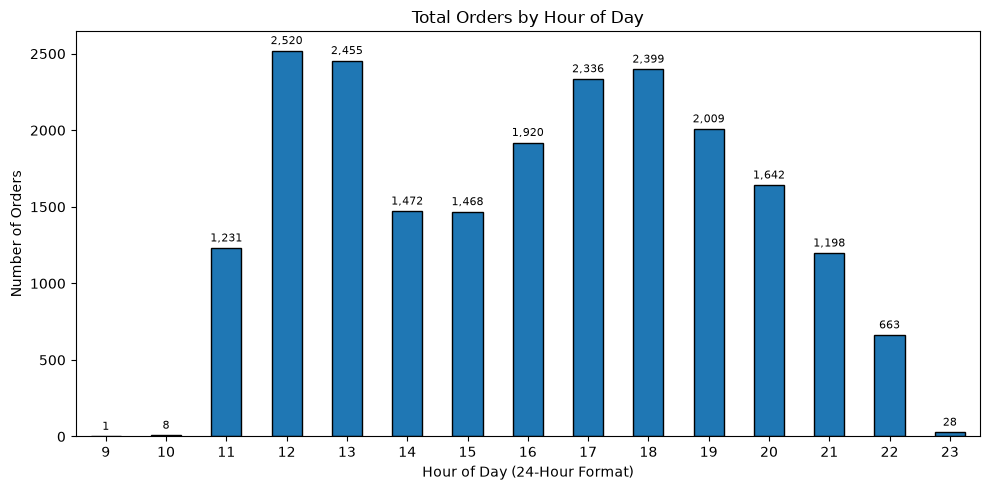

Peak ordering hour: 12:00 (2,520 orders)


In [ ]:
orders_by_hour = (
    df.groupby('order_hour')['order_id']
      .nunique()
      .sort_index()
)

ax = orders_by_hour.plot(
    kind='bar',
    figsize=(10, 5),
    edgecolor='black'
)

plt.title("Total Orders by Hour of Day")
plt.xlabel("Hour of Day (24-Hour Format)")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)

for idx, val in enumerate(orders_by_hour):
    ax.text(
        idx, val + orders_by_hour.max() * 0.01,
        f"{val:,}",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.show()

peak_hour = orders_by_hour.idxmax()
peak_hour_orders = orders_by_hour.max()
print(f"Peak ordering hour: {peak_hour}:00 ({peak_hour_orders:,} orders)")

## 📆 Monthly Order Trends

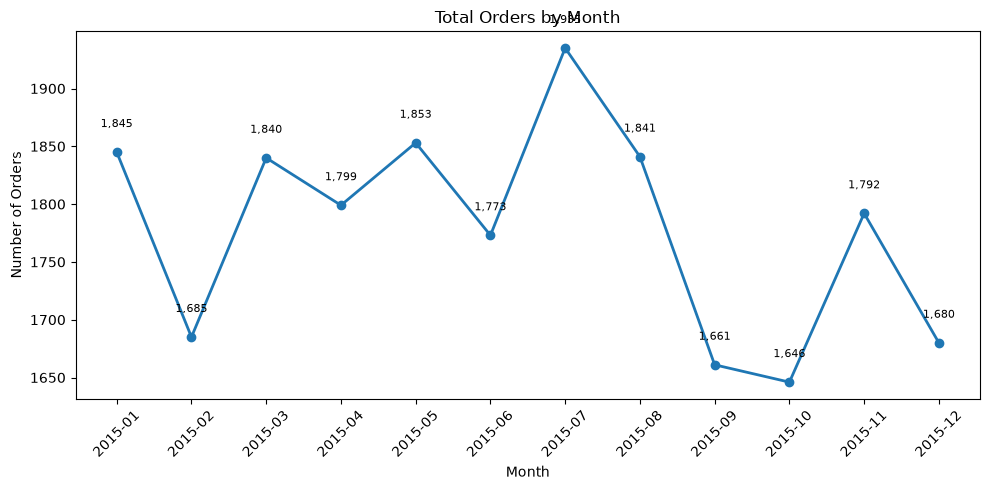

In [ ]:
orders_by_month = (
    df.groupby('month')['order_id']
      .nunique()
      .sort_index()
)

month_labels = orders_by_month.index.astype(str)

plt.figure(figsize=(10, 5))
plt.plot(
    month_labels,
    orders_by_month.values,
    linewidth=2,
    marker='o'
)
plt.title("Total Orders by Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

for idx, val in enumerate(orders_by_month):
    plt.text(
        idx, val + orders_by_month.max() * 0.01,
        f"{val:,}",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.show()

## 🍕 Sales Distribution by Pizza Category

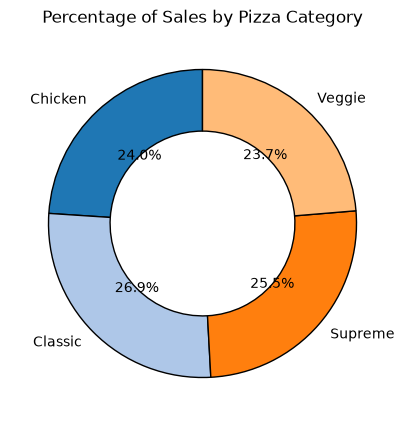

In [ ]:
category_sales = df.groupby(
    'pizza_category'
)['total_price'].sum()

category_pct = (
    category_sales / category_sales.sum()
) * 100

plt.figure(figsize=(6,5))

colors = plt.get_cmap('tab20').colors

plt.pie(
    category_pct,
    labels=category_pct.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={
        'edgecolor': 'black',
        'width': 0.4
    }
)

plt.title("Percentage of Sales by Pizza Category")
plt.show()


## 🔥 Category vs Size Sales Heatmap

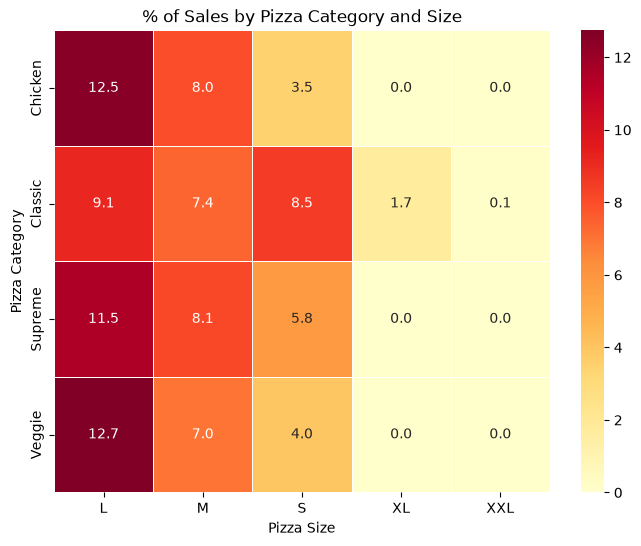

In [ ]:
sales_pivot = df.pivot_table(
    index='pizza_category',
    columns='pizza_size',
    values='total_price',
    aggfunc='sum',
    fill_value=0
)

sales_pct = (
    sales_pivot / sales_pivot.sum().sum()
) * 100

plt.figure(figsize=(8,6))

sns.heatmap(
    sales_pct,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("% of Sales by Pizza Category and Size")
plt.ylabel("Pizza Category")
plt.xlabel("Pizza Size")

plt.show()

## 📦 Total Pizzas Sold by Category

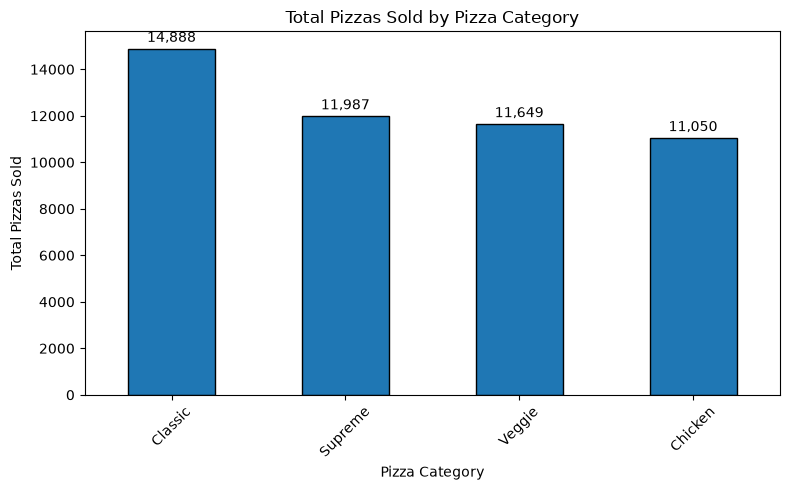

In [ ]:
pizzas_by_category = (
    df.groupby('pizza_category')['quantity']
      .sum()
      .sort_values(ascending=False)
)

ax = pizzas_by_category.plot(
    kind='bar',
    figsize=(8, 5),
    edgecolor='black'
)

plt.title("Total Pizzas Sold by Pizza Category")
plt.xlabel("Pizza Category")
plt.ylabel("Total Pizzas Sold")
plt.xticks(rotation=45)

for idx, val in enumerate(pizzas_by_category):
    ax.text(
        idx, val + pizzas_by_category.max() * 0.01,
        f"{val:,}",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

## 🥇 Top 10 Selling Pizzas

Identify the pizzas with the highest number of units sold.

,Pizzas Sold
pizza_name,
The Classic Deluxe Pizza,2453
The Barbecue Chicken Pizza,2432
The Hawaiian Pizza,2422
The Pepperoni Pizza,2418
The Thai Chicken Pizza,2371
The California Chicken Pizza,2370
The Sicilian Pizza,1938
The Spicy Italian Pizza,1924
The Southwest Chicken Pizza,1917


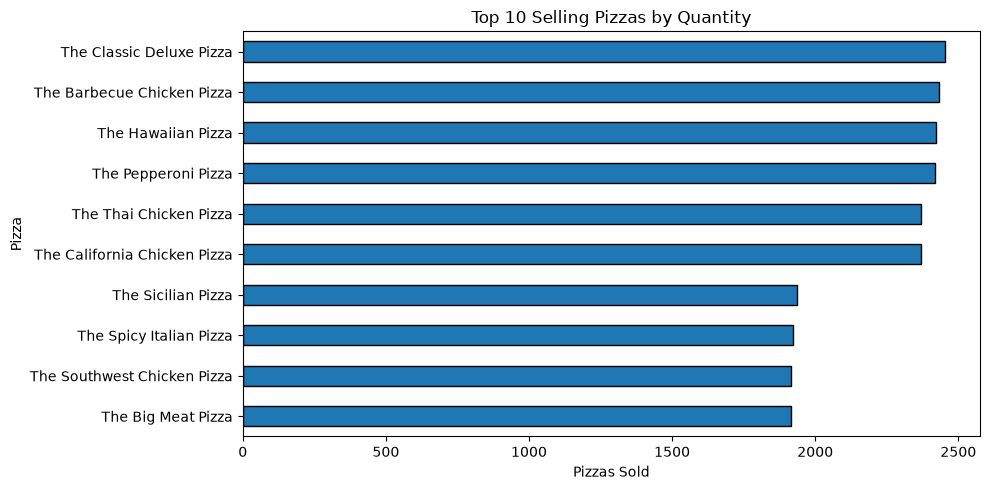

In [ ]:
top_selling_pizzas = (
    df.groupby('pizza_name')['quantity']
      .sum()
      .sort_values(ascending=False)
)

display(top_selling_pizzas.head(10).to_frame('Pizzas Sold'))

plt.figure(figsize=(10, 5))
top_selling_pizzas.head(10).sort_values().plot(kind='barh', edgecolor='black')
plt.title("Top 10 Selling Pizzas by Quantity")
plt.xlabel("Pizzas Sold")
plt.ylabel("Pizza")
plt.tight_layout()
plt.show()

## 💰 Top 10 Revenue-Generating Pizzas

Identify the pizzas contributing the most revenue.

,Revenue
pizza_name,
The Thai Chicken Pizza,43434.25
The Barbecue Chicken Pizza,42768.00
The California Chicken Pizza,41409.50
The Classic Deluxe Pizza,38180.50
The Spicy Italian Pizza,34831.25
The Southwest Chicken Pizza,34705.75
The Italian Supreme Pizza,33476.75
The Hawaiian Pizza,32273.25
The Four Cheese Pizza,32265.70


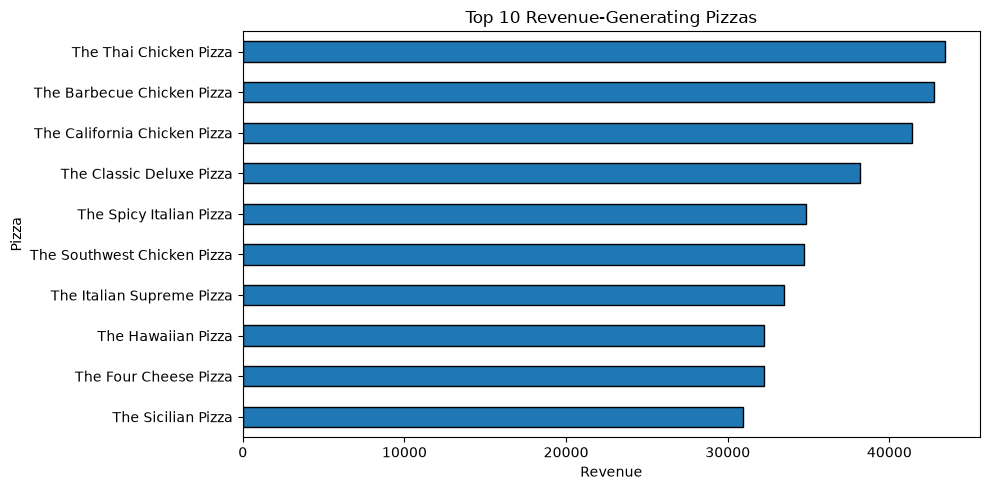

In [ ]:
revenue_by_pizza = (
    df.groupby('pizza_name')['total_price']
      .sum()
      .sort_values(ascending=False)
)

display(revenue_by_pizza.head(10).to_frame('Revenue'))

plt.figure(figsize=(10, 5))
revenue_by_pizza.head(10).sort_values().plot(kind='barh', edgecolor='black')
plt.title("Top 10 Revenue-Generating Pizzas")
plt.xlabel("Revenue")
plt.ylabel("Pizza")
plt.tight_layout()
plt.show()

## 📉 Bottom 10 Selling Pizzas

Identify the pizzas with the lowest unit sales so the business can review their performance.

,Pizzas Sold
pizza_name,
The Brie Carre Pizza,490
The Mediterranean Pizza,934
The Calabrese Pizza,937
The Spinach Supreme Pizza,950
The Soppressata Pizza,961
The Spinach Pesto Pizza,970
The Chicken Pesto Pizza,973
The Italian Vegetables Pizza,981
The Chicken Alfredo Pizza,987


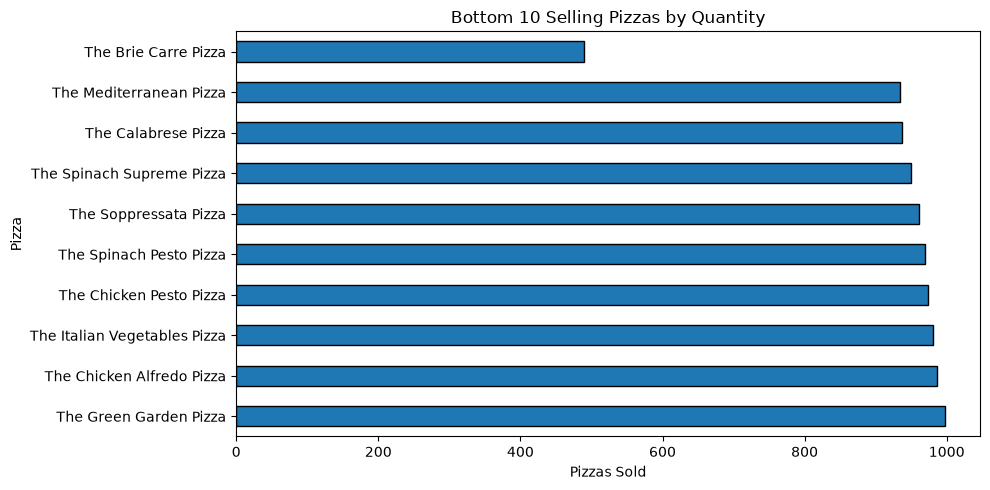

In [ ]:
bottom_selling_pizzas = (
    df.groupby('pizza_name')['quantity']
      .sum()
      .sort_values(ascending=True)
)

display(bottom_selling_pizzas.head(10).to_frame('Pizzas Sold'))

plt.figure(figsize=(10, 5))
bottom_selling_pizzas.head(10).sort_values(ascending=False).plot(
    kind='barh',
    edgecolor='black'
)
plt.title("Bottom 10 Selling Pizzas by Quantity")
plt.xlabel("Pizzas Sold")
plt.ylabel("Pizza")
plt.tight_layout()
plt.show()

## 🗓️ Weekend vs Weekday Sales

Compare customer demand between weekdays and weekends.

,total_orders,pizzas_sold,revenue
day_type,,,
Weekday,15568,36046,595474.15
Weekend,5782,13528,222385.90


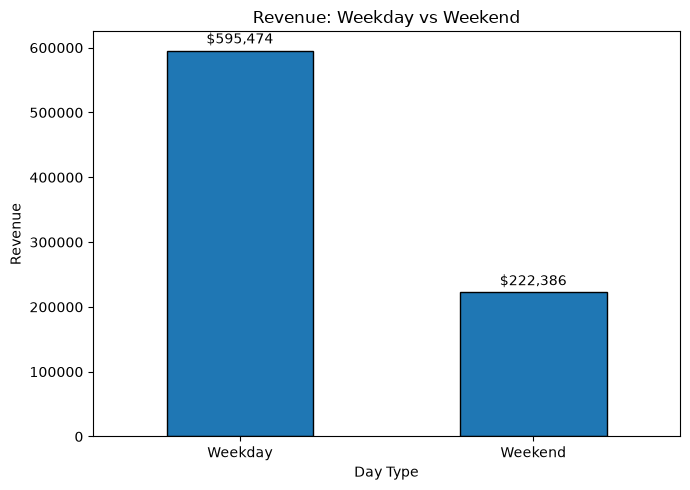

In [ ]:
weekend_weekday = (
    df.groupby('day_type', observed=False)
      .agg(
          total_orders=('order_id', 'nunique'),
          pizzas_sold=('quantity', 'sum'),
          revenue=('total_price', 'sum')
      )
      .reindex(['Weekday', 'Weekend'])
)

display(weekend_weekday)

plt.figure(figsize=(7, 5))
weekend_weekday['revenue'].plot(
    kind='bar',
    edgecolor='black'
)
plt.title("Revenue: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Revenue")
plt.xticks(rotation=0)

for idx, val in enumerate(weekend_weekday['revenue']):
    plt.text(
        idx, val + weekend_weekday['revenue'].max() * 0.01,
        f"${val:,.0f}",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

## 📊 Product Performance Summary

These metrics identify the strongest and weakest product performers without hardcoding any values.

In [ ]:
print("="*50)
print("            PIZZA SALES ANALYSIS ")
print("="*50)

print("\n💰 Total Revenue:")
print("Total Revenue = $817,860.05")

print("\n🛒 Total Orders:")
print("Total Orders = 21,350")

print("\n🍕 Total Pizzas Sold:")
print("Total Pizzas Sold = 49,574")

print("\n📦 Average Order Value:")
print("Average Order Value = $38.31")

print("\n🥇 Best Selling Category:")
print("Classic Pizzas")

print("\n📏 Most Preferred Size:")
print("Large (L)")

print("\n⏰ Peak Order Time:")
print("12 PM - 1 PM")


print("\n⭐ Average Pizzas per Order:")
print("2.32 Pizzas")



            PIZZA SALES ANALYSIS - KEY INSIGHTS

💰 Total Revenue:
Total Revenue = $817,860.05

🛒 Total Orders:
Total Orders = 21,350

🍕 Total Pizzas Sold:
Total Pizzas Sold = 49,574

📦 Average Order Value:
Average Order Value = $38.31

🥇 Best Selling Category:
Classic Pizzas

📏 Most Preferred Size:
Large (L)

⏰ Peak Order Time:
12 PM - 1 PM

⭐ Average Pizzas per Order:
2.32 Pizzas


Insights :

- Classic pizzas are the top-selling category.
- Large-sized pizzas are the most preferred by customers.
- Sales peak during lunch, dinner, and weekends.
- Customers order an average of 2.32 pizzas per transaction.
- A few popular pizzas drive a significant share of total revenue.

## ✅ Conclusion & Business Recommendations

- Use the **best-selling pizzas and categories** as core products and maintain strong inventory availability.
- Review the **bottom-selling pizzas** for pricing, product placement, promotion, or menu rationalization.
- Use the **highest-revenue pizzas** to understand which products contribute most to revenue, not just unit volume.
- Plan staffing and production around the **peak ordering hour** identified from the data.
- Compare **weekday vs weekend revenue** when planning promotions, staffing, and inventory.
- Use the **category and size analysis** to prioritize popular product combinations and optimize stock levels.
